In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
from pandas.tseries.offsets import DateOffset

np.set_printoptions(threshold=sys.maxsize)

os.chdir('C:/Users/kitteringhamrr/Desktop/Pymplnet/data')

#sets the threshold for the amount of data points (minutes) needed to take the hourly average
threshold = 10

#create empty arrays for all data for plotting purposes
df_ext_all = pd.DataFrame()
df_bscatter_all = pd.DataFrame()
df_aod_all = pd.DataFrame()
df_nrb_all = pd.DataFrame
df_lidr_all = pd.DataFrame()
df_pbl_all = pd.DataFrame()

#create string arrays with the titles of the csvs of each data type for every year from Jan 2021 - Jul 2025
bscatter_strs = np.array(["BACKSCATTER_L15_Y2021_M01-12_D01-31.csv", "BACKSCATTER_L15_Y2022_M01-12_D01-31.csv", "BACKSCATTER_L15_Y2023_M01-12_D01-31.csv", "BACKSCATTER_L15_Y2024_M01-12_D01-31.csv", "BACKSCATTER_L15_Y2025_M01-07_D01-31.csv"])
ext_strs = np.array(["EXTINCTION_L15_Y2021_M01-12_D01-31.csv", "EXTINCTION_L15_Y2022_M01-12_D01-31.csv", "EXTINCTION_L15_Y2023_M01-12_D01-31.csv", "EXTINCTION_L15_Y2024_M01-12_D01-31.csv", "EXTINCTION_L15_Y2025_M01-07_D01-31.csv"])
cld_strs = np.array(["CLOUD_BASE_L15_Y2021_M01-12_D01-31.csv", "CLOUD_BASE_L15_Y2022_M01-12_D01-31.csv", "CLOUD_BASE_L15_Y2023_M01-12_D01-31.csv", "CLOUD_BASE_L15_Y2024_M01-12_D01-31.csv", "CLOUD_BASE_L15_Y2025_M01-07_D01-31.csv"])
lidr_strs = np.array(["LIDAR_RATIO_L15_Y2021_M01-12_D01-31.csv","LIDAR_RATIO_L15_Y2022_M01-12_D01-31.csv","LIDAR_RATIO_L15_Y2023_M01-12_D01-31.csv","LIDAR_RATIO_L15_Y2024_M01-12_D01-31.csv","LIDAR_RATIO_L15_Y2025_M01-12_D01-31.csv"])
aod_strs = np.array(["AOD_L15_Y2021_M01-12_D01-31.csv", "AOD_L15_Y2022_M01-12_D01-31.csv", "AOD_L15_Y2023_M01-12_D01-31.csv", "AOD_L15_Y2024_M01-12_D01-31.csv", "AOD_L15_Y2025_M01-07_D01-31.csv"])
pbl_strs = np.array(["MIXED_LAYER_HEIGHT_L15_Y2021_M01-12_D01-31.csv", "MIXED_LAYER_HEIGHT_L15_Y2022_M01-12_D01-31.csv", "MIXED_LAYER_HEIGHT_L15_Y2023_M01-12_D01-31.csv", "MIXED_LAYER_HEIGHT_L15_Y2024_M01-12_D01-31.csv", "MIXED_LAYER_HEIGHT_L15_Y2025_M01-12_D01-31.csv"])
nrb_strs = np.array(["NRB_L15_Y2021_M01-12_D01-31.csv", "NRB_L15_Y2022_M01-12_D01-31.csv", "NRB_L15_Y2023_M01-12_D01-31.csv", "NRB_L15_Y2024_M01-12_D01-31.csv", "NRB_L15_Y2025_M01-07_D01-31.csv"])

In [5]:
for i in range(len(bscatter_strs)):
  #read in the csvs to Dataframes
  df_bscatter = pd.read_csv(bscatter_strs[i])
  df_cloud = pd.read_csv(cld_strs[i])
  df_ext = pd.read_csv(ext_strs[i])
  df_lidr = pd.read_csv(lidr_strs[i])

  #converts the time columns to pandas datetime objects
  df_cloud['time'] = pd.to_datetime(df_cloud['time'])
  df_bscatter['time'] = pd.to_datetime(df_bscatter['time'])
  df_ext['time'] = pd.to_datetime(df_ext['time'])
  df_lidr['time'] = pd.to_datetime(df_lidr['time'])

  #sets the indeces of every dataframe to the time column
  df_cloud_t = df_cloud.set_index('time')
  df_bscatter_t = df_bscatter.set_index('time')
  df_ext_t = df_ext.set_index('time')
  df_lidr_t = df_lidr.set_index('time')

  #puts the cloud data on both the extinction and the backscatter dfs
  df_cloudext = pd.concat([df_cloud_t, df_ext_t], axis = 1)
  df_cloudscatter = pd.concat([df_cloud_t, df_bscatter_t], axis = 1)
  df_cloudlidr = pd.concat([df_cloud_t, df_lidr_t], axis = 1)

  #drops all rows where there was a cloud from the extinction df and then drops the cloud column
  ext_index = df_cloudext[(df_cloudext['cloud_base'] == 1)].index
  df_cloudext.drop(ext_index, inplace = True)
  df_ext_clean = df_cloudext.drop(columns='cloud_base')

  #drops all rows where there was a cloud from the backscatter df and then drops the cloud column
  scatter_index = df_cloudscatter[(df_cloudscatter['cloud_base'] == 1)].index
  df_cloudscatter.drop(scatter_index, inplace = True)
  df_bscatter_clean = df_cloudscatter.drop(columns='cloud_base')

  #drops all rows where there was a cloud from the lidar ratio df and then drops the cloud column
  lidr_index = df_cloudlidr[(df_cloudlidr['cloud_base'] == 1)].index
  df_cloudlidr.drop(lidr_index, inplace = True)
  df_lidr_clean = df_cloudlidr.drop(columns='cloud_base')

  #creates a different backscatter ratio (lidar ratio) df by dividing the extinction df by the backscatter df
  df_bscatterratio_clean = df_ext_clean.divide(df_bscatter_clean)

  #creates hourly averages of the extinction data with the data count for each hour
  df_ext_count = df_ext_clean['1.155 km'].resample('h').count().to_frame(name="count")
  df_ext_avg = df_ext_clean.resample('h').mean()
  df_ext_countavg = pd.concat([df_ext_count,df_ext_avg], axis=1)

  #filters out any rows that have less than the threshold of counts (10 by default) for the df will all the data and drops the count column
  df_ext_filteredcount = df_ext_countavg[df_ext_countavg["count"] >= threshold]
  df_ext_filtered = df_ext_filteredcount.drop(columns=['count'])

  #creates hourly averages of the backscatter ratio data with the data count for each hour
  df_scatter_count = df_bscatterratio_clean['1.155 km'].resample('h').count().to_frame(name="count")
  df_scatter_avg = df_bscatterratio_clean.resample('h').mean()
  df_scatter_countavg = pd.concat([df_scatter_count,df_scatter_avg], axis=1)

  #filters out any rows that have less than the threshold of counts (10 by default) for the df will all the data and drops the count column
  df_scatter_filteredcount = df_scatter_countavg[df_scatter_countavg["count"] >= threshold]
  df_scatter_filtered = df_scatter_filteredcount.drop(columns=['count'])
  
  #creates hourly averages of the lidar ratio data with the data count for each hour
  df_lidr_count = df_lidr_t['lidar_ratio'].resample('h').count().to_frame(name="count")
  df_lidr_avg = df_lidr_t.resample('h').mean()
  df_lidr_countavg = pd.concat([df_lidr_count,df_lidr_avg], axis=1)

  #filters out any rows that have less than the threshold of counts (10 by default) for the df will all the data and drops the count column
  df_lidr_filteredcount = df_lidr_countavg[df_lidr_countavg["count"] >= threshold]
  df_lidr_filtered = df_lidr_filteredcount.drop(columns=['count']) 

  #add new data to the all data dataframe
  df_ext_all = pd.concat([df_ext_all, df_ext_filtered])
  df_bscatter_all = pd.concat([df_bscatter_all, df_scatter_filtered])
  df_lidr_all = pd.concat([df_lidr_all, df_lidr_filtered])

  #outputs the extinction and bscatter ratio dfs to csvs with the count of data in each hour in the first column, dropping any rows with a count of 0 (no data)
  df_ext_countavg.to_csv('HRAVG_NOCLOUD_'+ext_strs[i])
  df_scatter_countavg.to_csv('HRAVG_NOCLOUD_BACKSCATTERRATIO'+bscatter_strs[i].lstrip('BACKSCATTER'))
  df_lidr_countavg.to_csv('HRAVG_NOCLOUD_'+lidr_strs[i])

In [3]:
#does the exact same thing as the code above for the PBL heights
for i in range(len(pbl_strs)):
    df_cloud = pd.read_csv(cld_strs[i])
    df_cloud['time'] = pd.to_datetime(df_cloud['time'])
    df_cloud_t = df_cloud.set_index('time')

    df_pbl = pd.read_csv(pbl_strs[i])
    df_pbl['time'] = pd.to_datetime(df_pbl['time'])
    df_pbl_t = df_pbl.set_index('time')

    df_cloudpbl = pd.concat([df_cloud_t, df_pbl_t], axis = 1)

    index_pbl = df_cloudpbl[(df_cloudpbl['cloud_base'] == 1)].index
    df_cloudpbl.drop(index_pbl, inplace = True)
    df_pbl_clean = df_cloudpbl.drop(columns='cloud_base')

    df_pbl_cleaned = df_pbl_clean[df_pbl_clean['mixed_layer_height'] > 0.44968867]
    df_pbl_count = df_pbl_cleaned['mixed_layer_height'].resample('h').count().to_frame(name="count")
    df_pbl_avg = df_pbl_cleaned.resample('h').mean()
    df_pbl_countavg = pd.concat([df_pbl_count,df_pbl_avg], axis=1)

    df_pbl_countavg.to_csv('HRAVG_'+pbl_strs[i])

    df_pbl_filteredcount = df_pbl_countavg[df_pbl_countavg["count"] >= threshold]
    df_pbl_filtered = df_pbl_filteredcount.drop(columns=['count'])

    df_pbl_all = pd.concat([df_pbl_all, df_pbl_filtered])

In [ ]:
#does the exact same thing as the code above for the AOD and NRB data, no clouds are removed here however
for i in range(len(aod_strs)):
    df_aod = pd.read_csv(aod_strs[i])
    df_nrb = pd.read_csv(nrb_strs[i])

    df_aod['time'] = pd.to_datetime(df_aod['time'])
    df_nrb['time'] = pd.to_datetime(df_nrb['time'])

    df_aod_t = df_aod.set_index('time')
    df_nrb_t = df_nrb.set_index('time')

    df_aod_count = df_aod_t['aod'].resample('h').count().to_frame(name="count")
    df_aod_avg = df_aod_t.resample('h').mean()
    df_aod_countavg = pd.concat([df_aod_count,df_aod_avg], axis=1)

    df_aod_filteredcount = df_aod_countavg[df_aod_countavg["count"] >= threshold]
    df_aod_filtered = df_aod_filteredcount.drop(columns=['count'])

    df_nrb_count = df_nrb_t['1.380 km'].resample('h').count().to_frame(name="count")
    df_nrb_avg = df_nrb_t.resample('h').mean()
    df_nrb_countavg = pd.concat([df_nrb_count,df_nrb_avg], axis=1)

    df_nrb_filteredcount = df_nrb_countavg[df_nrb_countavg["count"] >= threshold]
    df_nrb_filtered = df_nrb_filteredcount.drop(columns=['count'])

    df_aod_countavg.to_csv('HRAVG_'+aod_strs[i])
    df_nrb_countavg.to_csv('HRAVG_'+nrb_strs[i])
    

In [58]:
#creates seasonally averaged dfs and seasonal std deviations for the extinction and bscatter ratio
df_ext_mo_avg = df_ext_all.resample('MS', label = 'left').mean()
df_ext_mo_std = df_ext_all.resample('MS', label = 'left').std()

df_scatter_mo_avg = df_bscatter_all.resample('MS', label = 'left').mean()
df_scatter_mo_std = df_bscatter_all.resample('MS', label = 'left').std()

df_scatter_mo_avg.to_csv('MOAVG_NOCLOUD_BACKSCATTERRATIO_L15_Y2021-2025.csv')

#creates seasonally averaged dfs and seasonal std deviations for the extinction and bscatter ratio
df_ext_seas_avg = df_ext_all.resample('Q-FEB', label = 'left').mean()
df_ext_seas_std = df_ext_all.resample('Q-FEB', label = 'left').std()

df_scatter_seas_avg = df_bscatter_all.resample('Q-FEB', label = 'left').mean()
df_scatter_seas_std = df_bscatter_all.resample('Q-FEB', label = 'left').std()

In [59]:
print(df_ext_seas_avg)

            1.155 km  1.230 km  1.305 km  1.380 km  1.455 km  1.530 km  \
time                                                                     
2020-11-30  0.040214  0.041849  0.043532  0.045278  0.033376  0.033250   
2021-02-28  0.030125  0.031514  0.032947  0.034439  0.022532  0.020444   
2021-05-31  0.068413  0.073118  0.079512  0.091609  0.057506  0.048748   
2021-08-31  0.049261  0.054777  0.063533  0.084133  0.031123  0.041824   
2021-11-30  0.065519  0.069160  0.073571  0.080151  0.063232  0.046311   
2022-02-28  0.054459  0.056951  0.059971  0.064555  0.052668  0.038843   
2022-05-31  0.072282  0.075336  0.078776  0.082854  0.076043  0.055732   
2022-08-31  0.047210  0.050174  0.053901  0.059354  0.039431  0.034272   
2022-11-30  0.086725  0.097344  0.112248  0.136038  0.107687  0.039596   
2023-02-28  0.054303  0.056546  0.058909  0.061424  0.049345  0.039608   
2023-05-31  0.116586  0.123497  0.132415  0.146638  0.129352  0.096129   
2023-08-31  0.053884  0.057168  0.0613

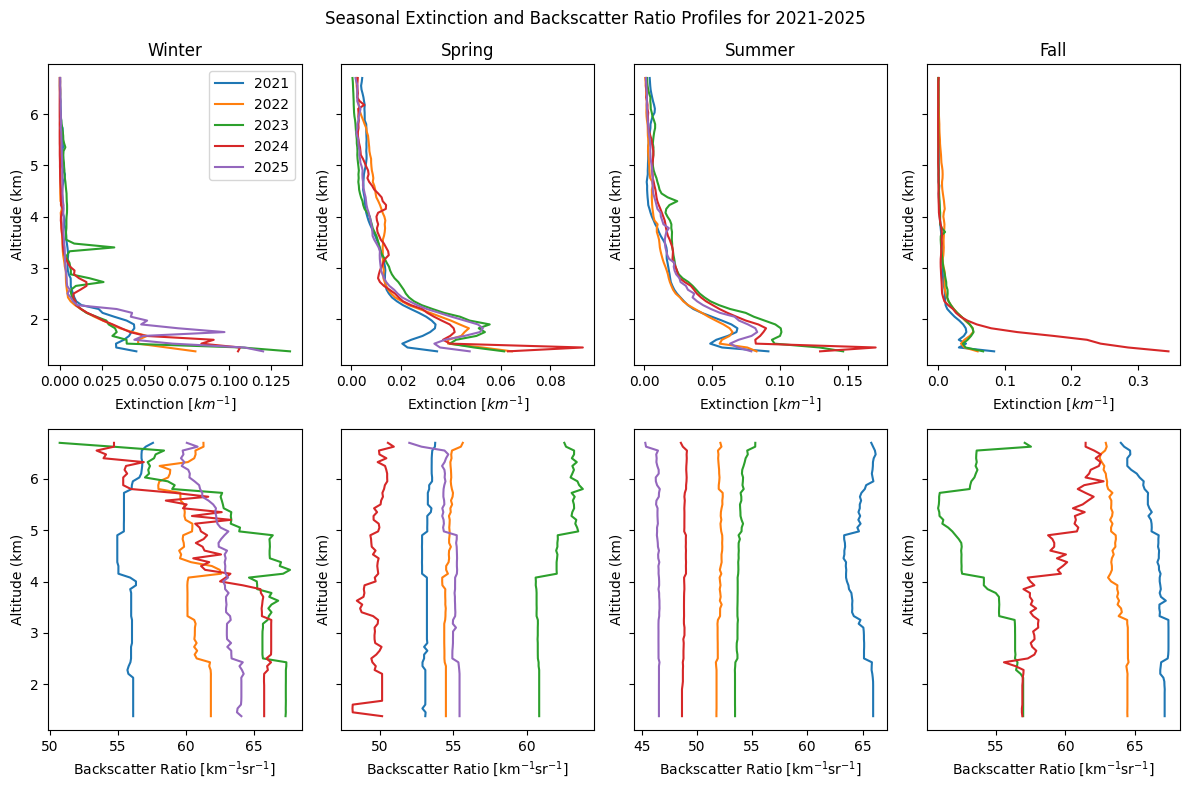

In [60]:
#creates an altiude array for the yaxis and plots a month of extinction and bscatter
#with standard deviation as the error bars
n = 0
alt = len(np.asarray(df_ext_seas_avg.columns))*[0]
for s in np.asarray(df_ext_seas_avg.columns):
  alt[n] = float(s.strip(' km'))
  n+=1
#time = '2025-01-01T00:00:00.000000000'
lim = 75 #sets the end point indeces for the points plotted.
#With each point being one 75 m altitude bin, 100 points is 7.5 km starting at 1 km
fig, axs = plt.subplots(2, 4, sharey=True, figsize=(12, 8))

#ax1.errorbar(np.asarray(df_ext_seas_avg.loc[time])[3:lim], alt[3:lim], xerr = np.asarray(df_ext_seas_std.loc[time])[3:lim], c = 'red', alpha = 0.4)
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[0]])[3:lim], alt[3:lim], label ='2021')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[4]])[3:lim], alt[3:lim], label ='2022')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[8]])[3:lim], alt[3:lim], label ='2023')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[12]])[3:lim], alt[3:lim], label ='2024')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[16]])[3:lim], alt[3:lim], label ='2025')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[1]])[3:lim], alt[3:lim], label ='2021')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[5]])[3:lim], alt[3:lim], label ='2022')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[9]])[3:lim], alt[3:lim], label ='2023')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[13]])[3:lim], alt[3:lim], label ='2024')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[17]])[3:lim], alt[3:lim], label ='2025')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[2]])[3:lim], alt[3:lim], label ='2021')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[6]])[3:lim], alt[3:lim], label ='2022')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[10]])[3:lim], alt[3:lim], label ='2023')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[14]])[3:lim], alt[3:lim], label ='2024')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[18]])[3:lim], alt[3:lim], label ='2025')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[3]])[3:lim], alt[3:lim], label ='2021')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[7]])[3:lim], alt[3:lim], label ='2022')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[11]])[3:lim], alt[3:lim], label ='2023')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[15]])[3:lim], alt[3:lim], label ='2024')

#ax2.errorbar(np.asarray(df_scatter_seas_avg.loc[time])[3:lim], alt[3:lim], xerr = np.asarray(df_scatter_seas_std.loc[time])[3:lim], c = 'red', alpha = 0.4)
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[0]])[3:lim], alt[3:lim], label ='2021')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[4]])[3:lim], alt[3:lim], label ='2022')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[8]])[3:lim], alt[3:lim], label ='2023')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[12]])[3:lim], alt[3:lim], label ='2024')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[16]])[3:lim], alt[3:lim], label ='2025')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[1]])[3:lim], alt[3:lim], label ='2021')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[5]])[3:lim], alt[3:lim], label ='2022')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[9]])[3:lim], alt[3:lim], label ='2023')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[13]])[3:lim], alt[3:lim], label ='2024')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[17]])[3:lim], alt[3:lim], label ='2025')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[2]])[3:lim], alt[3:lim], label ='2021')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[6]])[3:lim], alt[3:lim], label ='2022')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[10]])[3:lim], alt[3:lim], label ='2023')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[14]])[3:lim], alt[3:lim], label ='2024')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[18]])[3:lim], alt[3:lim], label ='2025')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[3]])[3:lim], alt[3:lim], label ='2021')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[7]])[3:lim], alt[3:lim], label ='2022')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[11]])[3:lim], alt[3:lim], label ='2023')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[15]])[3:lim], alt[3:lim], label ='2024')

axs[0,0].set_xlabel('Extinction [$km^{-1}$]')
axs[0,0].set_ylabel('Altitude (km)')
axs[0,0].set_title("Winter")
axs[0,0].legend()
axs[0,1].set_xlabel('Extinction [$km^{-1}$]')
axs[0,1].set_ylabel('Altitude (km)')
axs[0,1].set_title("Spring")
axs[0,2].set_xlabel('Extinction [$km^{-1}$]')
axs[0,2].set_ylabel('Altitude (km)')
axs[0,2].set_title("Summer")
axs[0,3].set_xlabel('Extinction [$km^{-1}$]')
axs[0,3].set_ylabel('Altitude (km)')
axs[0,3].set_title("Fall")

axs[1,0].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$')
axs[1,0].set_ylabel('Altitude (km)')
axs[1,1].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$')
axs[1,1].set_ylabel('Altitude (km)')
axs[1,2].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$')
axs[1,2].set_ylabel('Altitude (km)')
axs[1,3].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$')
axs[1,3].set_ylabel('Altitude (km)')

fig.suptitle('Seasonal Extinction and Backscatter Ratio Profiles for 2021-2025')
plt.tight_layout()
plt.savefig('SeasonalProfiles_Seasons_2021-2015_7km.png')

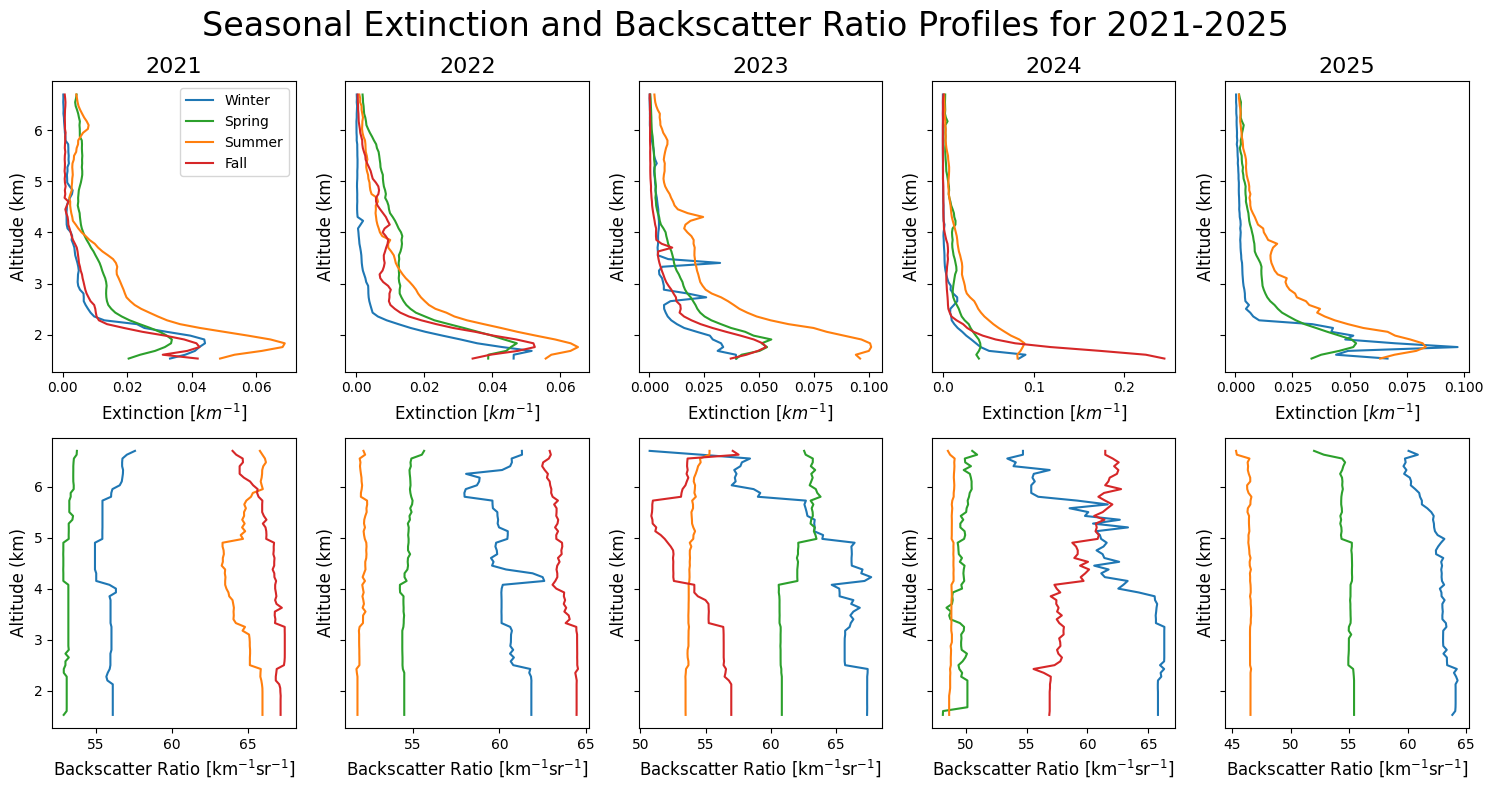

In [73]:
#creates an altiude array for the yaxis and plots a month of extinction and bscatter
#with standard deviation as the error bars
n = 0
alt = len(np.asarray(df_ext_seas_avg.columns))*[0]
for s in np.asarray(df_ext_seas_avg.columns):
  alt[n] = float(s.strip(' km'))
  n+=1
#time = '2025-01-01T00:00:00.000000000'
lowlim = 5
lim = 75 #sets the end point indeces for the points plotted.
#With each point being one 75 m altitude bin, 100 points is 7.5 km starting at 1 km
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['tab:blue', 'tab:green', 'tab:orange', 'tab:red'])

fig, axs = plt.subplots(2, 5, sharey=True, figsize=(15, 8))

#ax1.errorbar(np.asarray(df_ext_seas_avg.loc[time])[3:lim], alt[3:lim], xerr = np.asarray(df_ext_seas_std.loc[time])[3:lim], c = 'red', alpha = 0.4)
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[0]])[lowlim:lim], alt[lowlim:lim], label ='Winter')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[4]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[8]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[12]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[0,4].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[16]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[1]])[lowlim:lim], alt[lowlim:lim], label ='Spring')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[5]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[9]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[13]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[0,4].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[17]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[2]])[lowlim:lim], alt[lowlim:lim], label ='Summer')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[6]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[10]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[14]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[0,4].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[18]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[0,0].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[3]])[lowlim:lim], alt[lowlim:lim], label ='Fall')
axs[0,1].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[7]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[0,2].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[11]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[0,3].plot(np.asarray(df_ext_seas_avg.loc[df_ext_seas_avg.index[15]])[lowlim:lim], alt[lowlim:lim], label ='2024')

#ax2.errorbar(np.asarray(df_scatter_seas_avg.loc[time])[3:lim], alt[3:lim], xerr = np.asarray(df_scatter_seas_std.loc[time])[3:lim], c = 'red', alpha = 0.4)
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[0]])[lowlim:lim], alt[lowlim:lim], label ='2021')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[4]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[8]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[12]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[1,4].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[16]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[1]])[lowlim:lim], alt[lowlim:lim], label ='2021')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[5]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[9]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[13]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[1,4].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[17]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[2]])[lowlim:lim], alt[lowlim:lim], label ='2021')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[6]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[10]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[14]])[lowlim:lim], alt[lowlim:lim], label ='2024')
axs[1,4].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[18]])[lowlim:lim], alt[lowlim:lim], label ='2025')
axs[1,0].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[3]])[lowlim:lim], alt[lowlim:lim], label ='2021')
axs[1,1].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[7]])[lowlim:lim], alt[lowlim:lim], label ='2022')
axs[1,2].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[11]])[lowlim:lim], alt[lowlim:lim], label ='2023')
axs[1,3].plot(np.asarray(df_scatter_seas_avg.loc[df_scatter_seas_avg.index[15]])[lowlim:lim], alt[lowlim:lim], label ='2024')

axs[0,0].set_xlabel('Extinction [$km^{-1}$]', fontsize = 12)
axs[0,0].set_ylabel('Altitude (km)', fontsize = 12)
axs[0,0].set_title("2021", fontsize = 16)
axs[0,0].legend()
axs[0,1].set_xlabel('Extinction [$km^{-1}$]', fontsize = 12)
axs[0,1].set_ylabel('Altitude (km)', fontsize = 12)
axs[0,1].set_title("2022", fontsize = 16)
axs[0,2].set_xlabel('Extinction [$km^{-1}$]', fontsize = 12)
axs[0,2].set_ylabel('Altitude (km)', fontsize = 12)
axs[0,2].set_title("2023", fontsize = 16)
axs[0,3].set_xlabel('Extinction [$km^{-1}$]', fontsize = 12)
axs[0,3].set_ylabel('Altitude (km)', fontsize = 12)
axs[0,3].set_title("2024", fontsize = 16)
axs[0,4].set_xlabel('Extinction [$km^{-1}$]', fontsize = 12)
axs[0,4].set_ylabel('Altitude (km)', fontsize = 12)
axs[0,4].set_title("2025", fontsize = 16)

axs[1,0].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$', fontsize = 12)
axs[1,0].set_ylabel('Altitude (km)', fontsize = 12)
axs[1,1].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$', fontsize = 12)
axs[1,1].set_ylabel('Altitude (km)', fontsize = 12)
axs[1,2].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$', fontsize = 12)
axs[1,2].set_ylabel('Altitude (km)', fontsize = 12)
axs[1,3].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$', fontsize = 12)
axs[1,3].set_ylabel('Altitude (km)', fontsize = 12)
axs[1,4].set_xlabel('Backscatter Ratio [km$^{-1}$sr$^{-1}]$', fontsize = 12)
axs[1,4].set_ylabel('Altitude (km)', fontsize = 12)

fig.suptitle('Seasonal Extinction and Backscatter Ratio Profiles for 2021-2025', fontsize = 24)
plt.tight_layout()
plt.savefig('SeasonalProfiles_Years_2021-2015_7km.png')

In [74]:
print(df_bscatter_all)

Empty DataFrame
Columns: []
Index: []


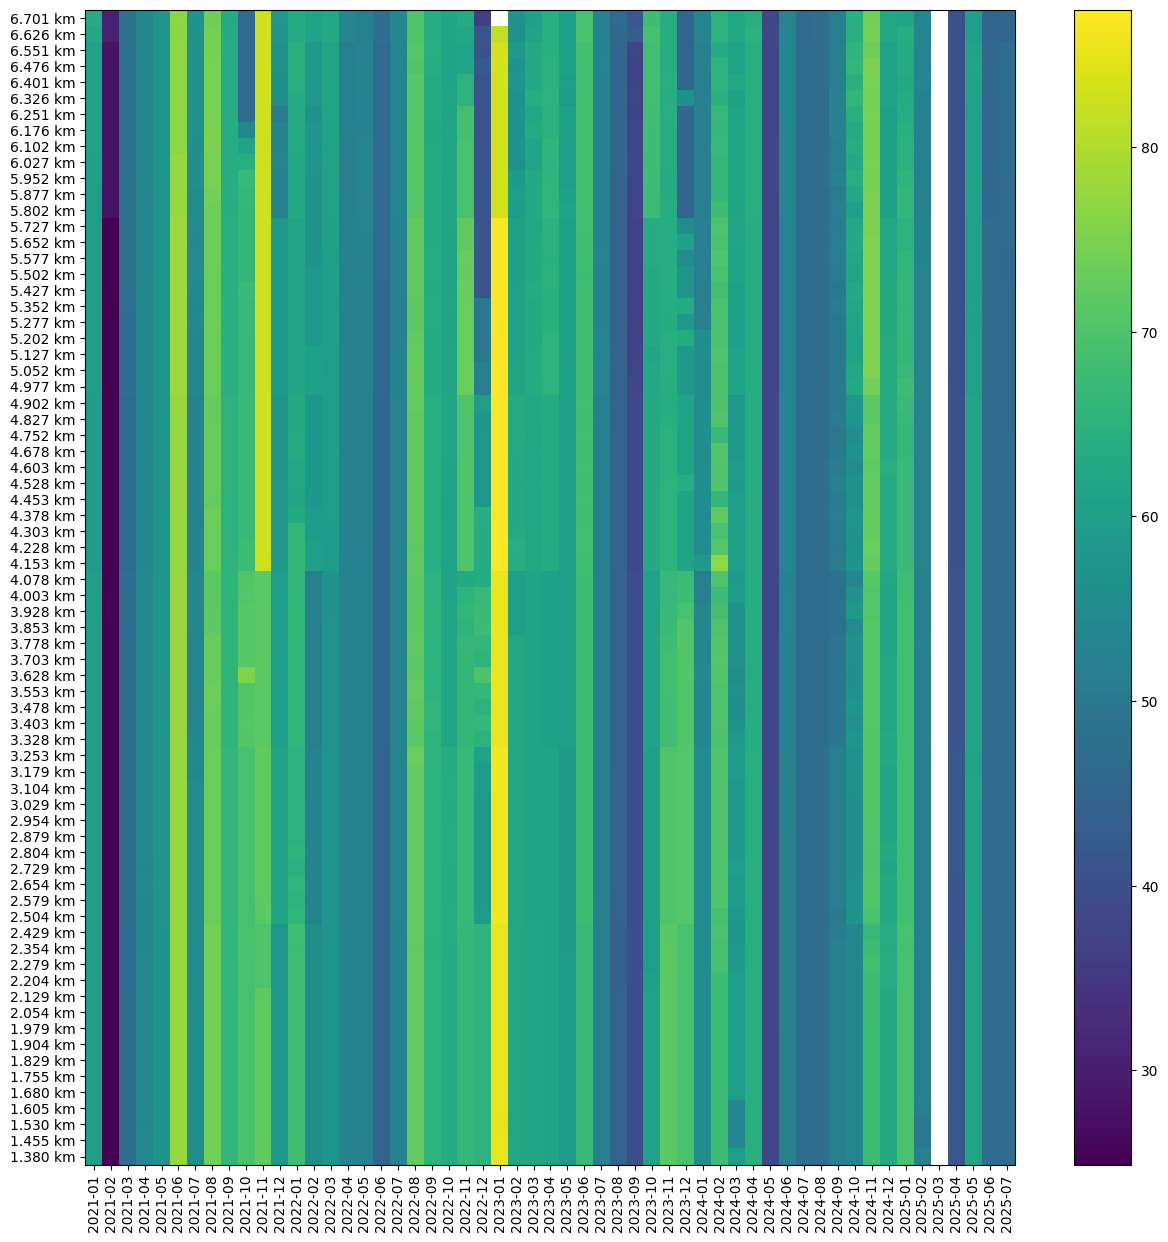

In [80]:
fig, ax = plt.subplots()

c = ax.pcolormesh(df_scatter_mo_avg.iloc[0:55,3:lim].transpose())
plt.colorbar(c)

ax.set_yticks(np.arange(lim-3)+0.5, minor=False)
ax.set_xticks(np.arange(df_scatter_mo_avg.shape[0])+0.5, minor=False)
ax.tick_params(axis='x', labelrotation=90)
ax.set_xticklabels(df_scatter_mo_avg.index.strftime('%Y-%m'), minor=False)
ax.set_yticklabels(df_scatter_mo_avg.columns[3:lim], minor=False)
plt.show()


plt.rcParams['figure.figsize'] = [15, 15]

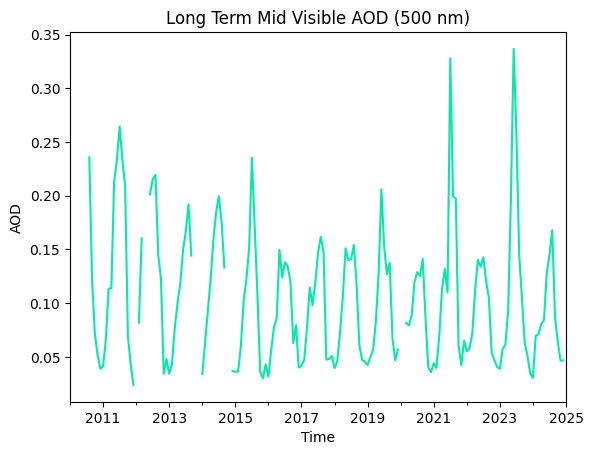

In [12]:
df_aero = pd.read_csv("AODScatAbsPM25_2010-2025.csv")
df_aero['DateTime'] = pd.to_datetime(df_aero['DateTime'], format = '%m/%d/%Y %H:%M')

df_aero = df_aero.set_index(['DateTime'])
df_aero_avg = df_aero.resample('MS').mean()

#df_aero_avg["AOD_1020nm"].plot()
#df_aero_avg["AOD_870nm"].plot()
#df_aero_avg["AOD_675nm"].plot()
df_aero_avg["AOD_500nm"].plot(title = "Long Term Mid Visible AOD (500 nm)", ylabel="AOD", xlabel = 'Time', color = ['#00ECA8'])#, xticks = pd.to_datetime([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], format = "%Y"))
#df_aero_avg["AOD_440nm"].plot()
#df_aero_avg["AOD_380nm"].plot()
#df_aero_avg["AOD_340nm"].plot()
plt.savefig("LongtermMidVisAOD.png")

In [28]:
df_AOD500nm = df_aero[["AOD_500nm"]]
xticks = pd.date_range(start='1/1/2010', end = '1/1/2025', freq = "MS")
ax = df_AOD500nm.groupby(pd.Grouper(key='time', axis=0, freq='M')).boxplot(subplots=False, figsize=(30,9), rot=90, labels = xticks)
ax.set_xticks = xticks
plt.show()

KeyError: 'The grouper name time is not found'

<Axes: xlabel='time'>

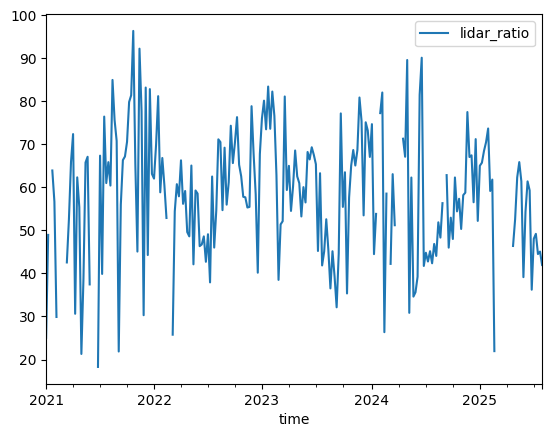

In [19]:
df_lidr_W = df_lidr_all.resample('W').mean()
df_lidr_W.plot()

<Axes: >

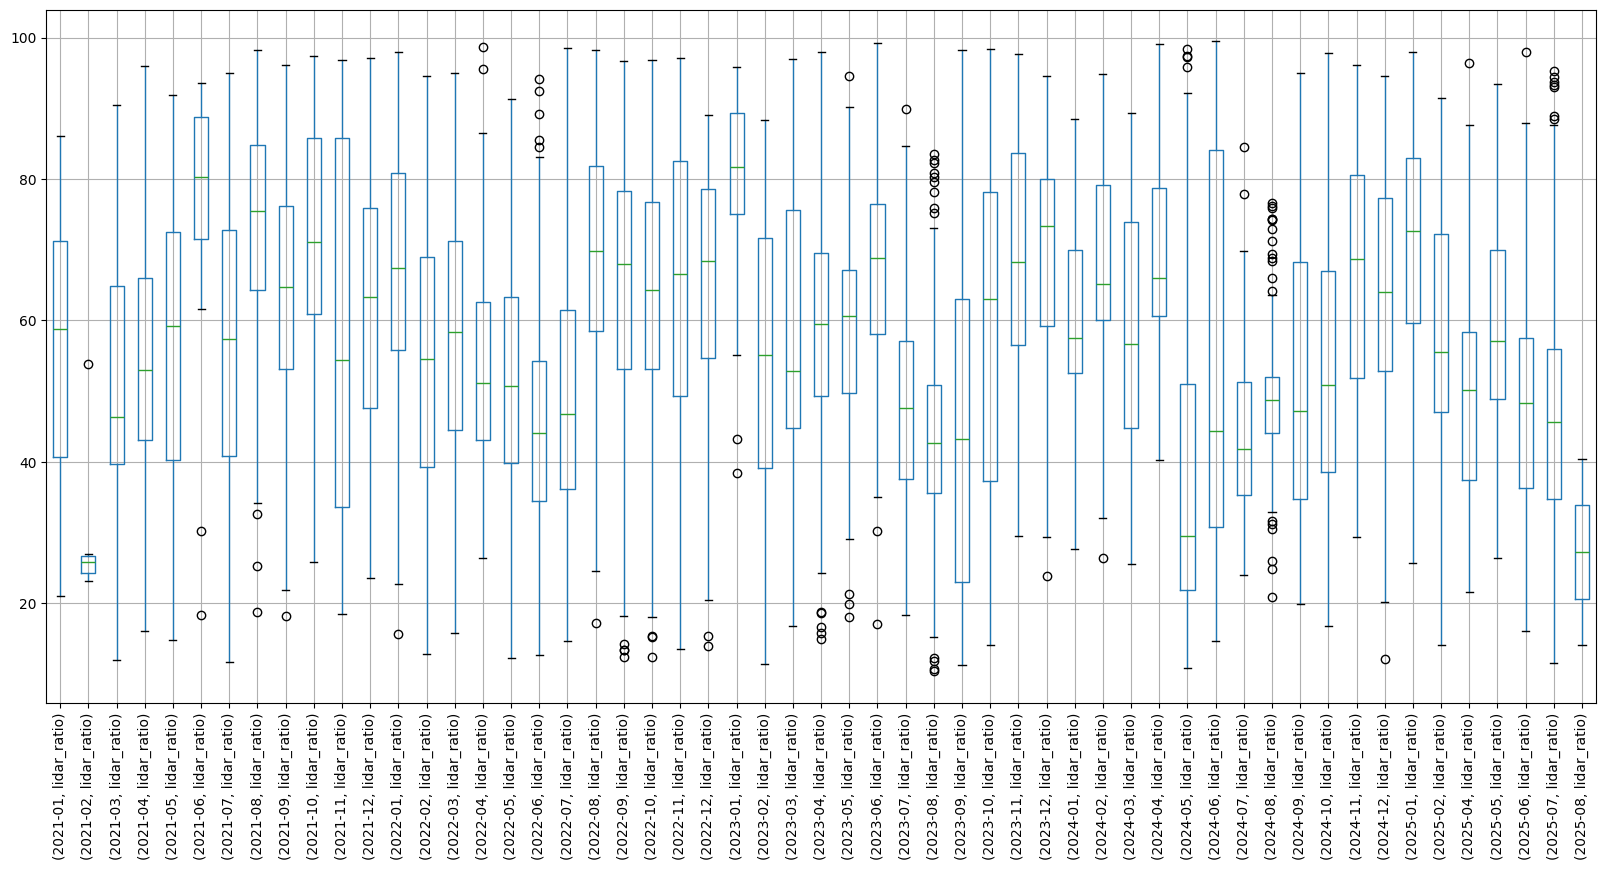

In [10]:
df_lidr_all.groupby(lambda x: x.strftime("%Y-%m")).boxplot(subplots=False, figsize=(20,9), rot=90)